# scGPT–scVI Dissimilarity Analysis and Distribution Visualization

Author: Yuxuan Xu

Description:
This notebook compares the structural difference between scGPT and scVI
embeddings using cell-wise kNN graph dissimilarity.

The analysis focuses on:
- computing dissimilarity between scGPT and scVI embeddings
- summarizing the global average dissimilarity
- visualizing the distribution of cell-wise dissimilarity values
- displaying dissimilarity on UMAP

Main steps:
- Construct kNN graphs from scGPT and scVI embeddings
- Convert connectivity graphs to adjacency matrices
- Compute cell-wise Jaccard dissimilarity
- Plot dissimilarity distribution using boxplot and violin plot
- Visualize dissimilarity values on UMAP

Goals:
- Quantify the structural difference between scGPT and scVI embeddings
- Examine how dissimilarity is distributed across cells
- Identify regions with higher disagreement between embeddings

Inputs:
- AnnData objects containing scGPT and scVI embeddings
- kNN graphs or connectivity matrices derived from these embeddings

Outputs:
- Cell-wise dissimilarity scores
- Global mean dissimilarity
- Boxplot and violin plot of dissimilarity distribution
- UMAP visualization colored by dissimilarity

Notes:
- Dissimilarity is based on Jaccard distance between kNN graphs
- Higher values indicate larger structural differences
- Distribution plots help show spread, density, and variability across cells

In [1]:
import scatlastb_utils as atl
help(atl.metrics.get_adjacency)
import anndata as ad
import scanpy as sc

adata_1 = sc.read_h5ad("/home/ubuntu/sclecture_fm_benchmark/notebooks/explore/data/cxg/retina_ganglion_ex_midget.h5ad")
adata_2 = sc.read_h5ad("/home/ubuntu/sclecture_fm_benchmark/notebooks/retina_scgpt_cell_emb_finetuned_umap.h5ad")

print("obsp:", list(adata_1.obsp.keys()))
print("obsp:", list(adata_2.obsp.keys()))

/home/ubuntu/miniforge/envs/scanpy/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Help on function get_adjacency in module scatlastb_utils.metrics.knn_overlap:

get_adjacency(X, weighted: bool, k: int = 1, _lambda: float = 1, tol: float = 1e-05, use_dask: bool = False, chunk_size: int = 50000)
    Retrieve adjacency matrix from distances or connectivities.
    
    :param weighted: whether to preserve weighting of adjacency or return unweighted adjacency
        Default: weighted=False - 1 when edge present, 0 when edge not present
    :param k: power of matrix multiplication. Computationally expensive and densifies the matrix.
        Default: 1, no multiplication performed.



/home/ubuntu/miniforge/envs/scanpy/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


obsp: []
obsp: ['nbrs_scgpt_ft_connectivities', 'nbrs_scgpt_ft_distances']


In [2]:
print(adata_2.obsm.keys())
print(adata_1.obsm.keys())

KeysView(AxisArrays with keys: X_scGPT, X_scGPT_finetuned, X_scVI, X_umap, X_umap_scgpt_ft)
KeysView(AxisArrays with keys: X_scVI, X_umap)


In [3]:
# ==========================================
# Step 1: Compute kNN graphs for each embedding
# ==========================================
sc.pp.neighbors(adata_1, use_rep="X_scVI", key_added="scvi", n_neighbors=15)
sc.pp.neighbors(adata_2, use_rep="X_scGPT", key_added="scgpt_orig", n_neighbors=15)

# ==========================================
# Step 2: Extract precomputed connectivity matrices (sparse)
# ==========================================
# Scanpy automatically appends "_connectivities" to the key
graph_A = adata_1.obsp["scvi_connectivities"]
graph_B = adata_2.obsp["scgpt_orig_connectivities"]

# ==========================================
# Step 3: Convert to adjacency matrices using scAtlasTb
# ==========================================
A = atl.metrics.get_adjacency(graph_A, weighted=False, k=1)
B = atl.metrics.get_adjacency(graph_B, weighted=False, k=1)

In [4]:
import numpy as np

def dissimilarity(A, B, eps=1e-12):
    # Convert the Sparse matrix to the CSR format (Compressed Sparse Row)
    # Copy a matrix to avoid modifying the original object when you later change A.data
    A = A.tocsr().copy()
    B = B.tocsr().copy()

    # binaryzation: Set the values of all non-zero elements to 1
    # Only care about "whether there is an edge or not", not what the weight of the edge is
    A.data[:] = 1
    B.data[:] = 1

    # Calculate the size of the intersection of neighbors for each cell
    inter = np.asarray(A.multiply(B).getnnz(axis=1), dtype=float)
    dA = np.asarray(A.getnnz(axis=1), dtype=float)
    dB = np.asarray(B.getnnz(axis=1), dtype=float)

    # Jaccard
    union = dA + dB - inter
    sim = np.where(union > 0, inter / (union + eps), 0.0)

    # F1
    # denom = dA + dB
    # sim = np.where(denom > 0, 2 * inter / denom, 0.0)
    return 1 - sim

# # Compute and print the global average dissimilarity

print(dissimilarity(A, B))

[1.         1.         0.97619048 ... 0.96428571 1.         1.        ]


In [5]:
graphs = {
    "scvi": adata_1.obsp["scvi_connectivities"],
    "scgpt": adata_2.obsp["scgpt_orig_connectivities"]
}

# ==========================================
# Step 3: Iterate through graphs and convert them to adjacency matrices
# ==========================================
adj = {}

for name, G in graphs.items():
    adj[name] = atl.metrics.get_adjacency(G, weighted=False, k=1)

# Verify that the adjacency matrices were created successfully
print("Generated adjacency matrices:", adj.keys())

生成的邻接矩阵包含: dict_keys(['scvi', 'scgpt'])


In [6]:
print(adata_1.n_obs, adata_2.n_obs)

20587 20587


In [7]:
print((adata_1.obs_names == adata_2.obs_names).all())

True


In [8]:
print(adj["scgpt"].shape)

(20587, 20587)


In [13]:
dissim_results = {}
for name, G in graphs.items():
    if name == "scgpt":
        continue
    vec = dissimilarity(graphs["scgpt"], G)
    dissim_results[name] = vec
    adata_2.obs[f"dissim_scgpt_vs_{name}"] = vec

In [14]:
for name, vec in dissim_results.items():
    print(f"scgpt vs {name}: mean dissimilarity = {vec.mean():.4f}")

scgpt vs scvi: mean dissimilarity = 0.9922


In [15]:
import pandas as pd
names = list(graphs.keys())
mean_dissim = pd.DataFrame(index=names, columns=names, dtype=float)

for n1 in names:
    for n2 in names:
        mean_dissim.loc[n1, n2] = dissimilarity(graphs[n1], graphs[n2]).mean()

mean_dissim

,scvi,scgpt
scvi,5.221727e-14,9.922069e-01
scgpt,9.922069e-01,5.179374e-14


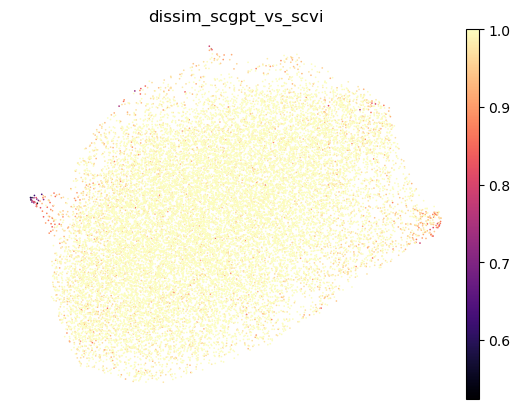

In [27]:
sc.pl.embedding(
    adata_2,  # use the AnnData object where results were stored
    basis="X_umap",  # UMAP coordinates (use "X_umap_scgpt_ft" if you want the fine-tuned version)
    color=[
        "dissim_scgpt_vs_scvi",  # must match the column name generated earlier
    ],
    cmap="magma",  # recommended colormap (e.g. magma or viridis) to highlight dissimilarity levels
    frameon=False,
    ncols=1,
    save="_dissim_scgpt_vs_scvi.pdf"
)

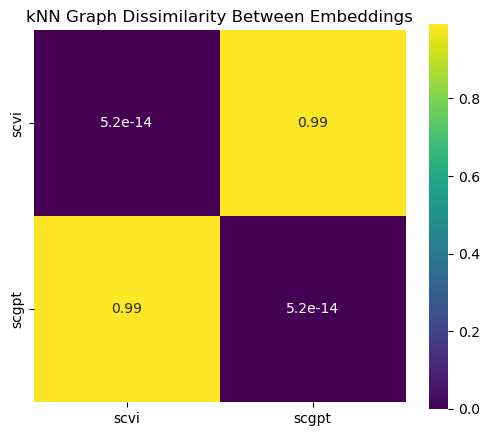

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    mean_dissim,
    annot=True,        
    cmap="viridis",    
    square=True
)

plt.title("kNN Graph Dissimilarity Between Embeddings")
plt.tight_layout
plt.savefig("kNN_Graph_Dissimilarity_Heatmap.pdf", bbox_inches="tight")
plt.show()

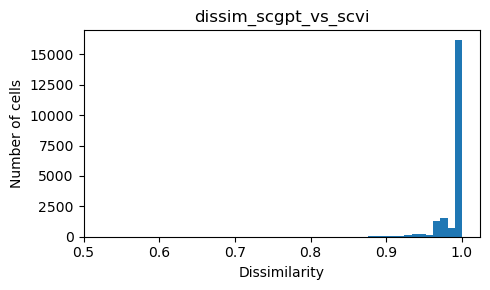

In [29]:
for col in [
    "dissim_scgpt_vs_scvi",
]:
    plt.figure(figsize=(5, 3))
    plt.hist(adata_1.obs[col], bins=50)
    plt.title(col)
    plt.xlabel("Dissimilarity")
    plt.ylabel("Number of cells")
    plt.tight_layout()
    plt.savefig(f"{col}_histogram.pdf", bbox_inches="tight")
    plt.show()

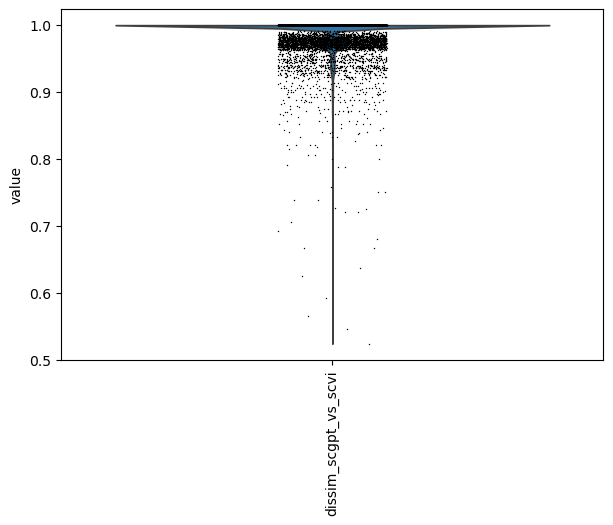

In [30]:
sc.pl.violin(
    adata_2,
    keys=[
        "dissim_scgpt_vs_scvi",
    ],
    #groupby="majorclass",
    rotation=90,
    save="_dissim_scgpt_vs_scvi_overall.pdf"
)

In [25]:
for name, G in graphs.items():
    print(name, "mean neighbors:", G.getnnz(axis=1).mean())

scvi mean neighbors: 21.35318404818575
scgpt mean neighbors: 21.653859231553895
